![imagen](https://images.datacamp.com/image/upload/v1700043905/image10_f8b261ebf1.png)

In [ ]:
!python -V

Python 3.12.11


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.callbacks import EarlyStopping
import math

print(tf.__version__)
print(tfds.__version__)



2.19.0
4.9.9


In [ ]:
# Descargar set de datos de MNIST (números escritos a mano, etiquetados)
datos, metadatos = tfds.load('mnist', as_supervised=True, with_info=True)

# Obtener en variables separadas los datos de entrenamiento (60k) y pruebas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

# Función de normalización para los datos (pasar valores de los píxeles de 0-255 a 0-1)
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32) / 255.0  # Normalizar a [0, 1]
    imagenes = tf.expand_dims(imagenes, axis=-1)  # Añadir el canal de profundidad
    return imagenes, etiquetas

# Normalizar los datos de entrenamiento y prueba
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)


# Agregar a cache (usar memoria en lugar de disco, entrenamiento más rápido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()
clases = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RB220K_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.RB220K_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


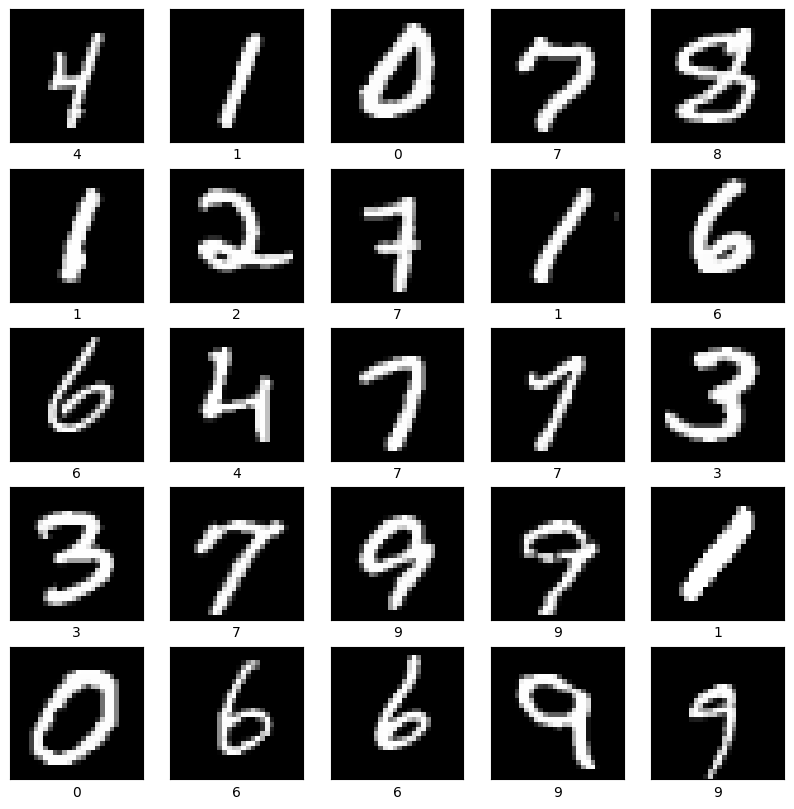

In [ ]:
#Codigo para mostrar imagenes del set, no es necesario ejecutarlo, solo imprime unos numeros :)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  imagen = imagen.numpy().reshape((28,28))
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary_r)
  plt.xlabel(clases[etiqueta])

plt.show()

Este es un modelo de red neuronal convolucional (CNN) diseñado para trabajar con imágenes de 28x28 píxeles, como las del conjunto de datos MNIST. El modelo consta de varias capas, que son:

**Capa de entrada (Input):** Define la forma de entrada de las imágenes. En este caso, las imágenes son en escala de grises con una dimensión de (28, 28, 1).


**Capas de convolución (Conv2D):**


**Conv2D(32, (3, 3), activation='relu'):**

32: Número de filtros (kernels). Cada filtro aprenderá a detectar características diferentes en las imágenes.
(3, 3): Tamaño del kernel. Es un filtro de 3x3 píxeles.
activation='relu': Función de activación que introduce no linealidad.

**Capas de agrupamiento (MaxPooling2D):**

MaxPooling2D((2, 2)): Esta capa reduce las dimensiones espaciales de la salida de la capa anterior. En este caso, se aplica un agrupamiento de 2x2, que toma el valor máximo en cada ventana de 2x2, reduciendo así la resolución.
Capa de aplanamiento (Flatten): Convierte la salida de las capas anteriores en un vector unidimensional para que pueda ser procesado por las capas densas.

![image](https://miro.medium.com/v2/resize:fit:1400/0*QIvqCOigRiq1Gmnc.png)

**Capas densas (Dense):**

La primera capa densa tiene 100 unidades y usa la activación ReLU.
La última capa densa tiene 10 unidades (una por cada clase en el conjunto de datos MNIST) y usa la activación softmax para obtener probabilidades.
Determinación de los Kernels

Los kernels (o filtros) en las capas de convolución son matrices pequeñas que se deslizan (convolucionan) sobre la imagen de entrada para extraer características. Aquí hay algunos puntos clave sobre su determinación y uso:

**Tamaño del Kernel:**

En este caso, el kernel tiene un tamaño de (3, 3). Este tamaño se elige a menudo en función de las características que se desean detectar. Kernels más pequeños (como 3x3 o 5x5) son comunes porque pueden capturar patrones locales de manera efectiva.
Número de Filtros:

En Conv2D(32, ...), el número 32 indica que se están utilizando 32 filtros diferentes. Cada filtro se entrena para aprender diferentes características de la imagen (bordes, texturas, etc.).
Entrenamiento:


Los valores de los kernels son parámetros que se ajustan durante el entrenamiento del modelo. Al inicio, los valores se inicializan aleatoriamente, y durante el entrenamiento, a través del proceso de retropropagación, se ajustan en función del error del modelo.




In [ ]:
#Crear el modelo (Ya utiliza capas de convolución y agrupación)
#Cuenta con 1 capa de convolución con 32 núcleos y otra con 64. 2 capas de agrupación.
#Finalmente una capa densa con 100 neuronas
# Crear el modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),  # Usar Input para definir la forma de entrada
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), padding="same"),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])


# Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,746 (659.16 KB)

 Trainable params: 168,746 (659.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Trabajar por lotes
TAMANO_LOTE = 32

# Shuffle y repeat hacen que los datos estén mezclados de manera aleatoria
# para que el entrenamiento no se aprenda en orden
datos_entrenamiento = datos_entrenamiento.shuffle(10000).batch(TAMANO_LOTE).repeat()
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [ ]:
# Configurar EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Realizar el entrenamiento
num_datos_entrenamiento = metadatos.splits['train'].num_examples
num_datos_entrenamiento

60000

In [ ]:
# Realizar el entrenamiento
historial = modelo.fit(
    datos_entrenamiento,
    epochs=50,
    steps_per_epoch=math.ceil(num_datos_entrenamiento / TAMANO_LOTE),
    validation_data=datos_pruebas,
    validation_steps=math.ceil(len(list(datos_pruebas)) / TAMANO_LOTE),
    callbacks=[early_stopping]
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8860 - loss: 0.3519 - val_accuracy: 0.9719 - val_loss: 0.0553
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9833 - loss: 0.0523 - val_accuracy: 0.9906 - val_loss: 0.0227
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9897 - loss: 0.0339 - val_accuracy: 0.9844 - val_loss: 0.0391
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9911 - loss: 0.0277 - val_accuracy: 0.9906 - val_loss: 0.0415
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9928 - loss: 0.0215 - val_accuracy: 0.9937 - val_loss: 0.0300
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9939 - loss: 0.0174 - val_accuracy: 0.9875 - val_loss: 0.0451
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9937 - val_loss: 0.0281


In [ ]:
# Guardar el modelo en el formato nativo de Keras
modelo.save('numerosC2.keras')
#modelo.save('numerosC2.h5')

In [ ]:
model_json = modelo.to_json()
with open('numeros2.json', 'w') as json_file:
    json_file.write(model_json)
modelo.save_weights('numeros2.weights.h5') # Change the file name to end with .weights.h5

In [ ]:
#Exportar el modelo al explorador! (Mas detalle de esto en en mi video de exportacion: https://youtu.be/JpE4bYyRADI )
#modelo.save('numeros_conv.h5')

#Convertirlo a tensorflow.js
#!pip install tensorflowjs

#!mkdir carpeta_salida

#!tensorflowjs_converter --input_format keras numeros_conv.h5 carpeta_salida

In [ ]:
# Print the final training and validation accuracy
print("Final Training Accuracy: {:.4f}".format(historial.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(historial.history['val_accuracy'][-1]))

Final Training Accuracy: 0.9983
Final Validation Accuracy: 0.9906


## Descargar Imagen


In [ ]:
import requests

url = "https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/numero9.jpg"
response = requests.get(url)

if response.status_code == 200:
    with open("numero2.jpg", "wb") as f:
        f.write(response.content)
    print("Image downloaded successfully as numero2.jpg")
else:
    print(f"Failed to download image. Status code: {response.status_code}")

Image downloaded successfully as numero2.jpg


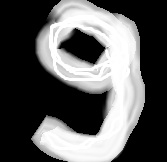

In [ ]:
#mostrar imagen en colab
from IPython.display import Image
Image(filename='numero2.jpg')

## Preprocesamiento de la imagen


In [ ]:
import cv2
import numpy as np

# Load the image in grayscale
image_path = 'numero2.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Resize the image to 28x28
image_resized = cv2.resize(image, (28, 28))

# Normalize the pixel values to [0, 1]
image_normalized = image_resized.astype(np.float32) / 255.0

# Add a channel dimension
image_preprocessed = np.expand_dims(image_normalized, axis=-1)

# Add a batch dimension (the model expects a batch of images)
image_preprocessed = np.expand_dims(image_preprocessed, axis=0)

print("Image preprocessed successfully. Shape:", image_preprocessed.shape)

Image preprocessed successfully. Shape: (1, 28, 28, 1)


## Predecir el digito




In [ ]:
# Use the trained model to predict the digit
predictions = modelo.predict(image_preprocessed)

# Get the predicted digit (index with the highest probability)
predicted_digit = np.argmax(predictions)

print(f"The predicted digit is: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The predicted digit is: 9


## Desplegamos la predicción



In [ ]:
print(f"The predicted digit is: {predicted_digit}")

The predicted digit is: 9


In [ ]:
# Extraer métricas del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

epocas = range(1, len(acc) + 1)

# Gráfica de precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Entrenamiento')
plt.plot(epocas, val_acc, 'r-', label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Entrenamiento')
plt.plot(epocas, val_loss, 'r-', label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()